Suavido de punto de interes

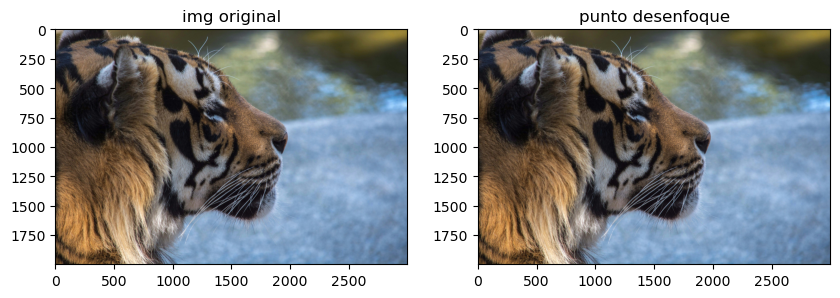

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def desenfoquePDT(img, centro, x, y):
    img1 = np.copy(img)
    valx,valy = centro
    mediax = x//2
    mediaY = y//2
    mascara = np.zeros_like(img, dtype=np.uint8)
    cv2.ellipse(mascara,(valx,valy),(mediax,mediaY),0,0,360,(255,255,255),-1)
    img_mask = cv2.bitwise_and(img,mascara)
    desenmfoque = cv2.GaussianBlur(img_mask,(15,15),0)
    img1[mascara!=0] = desenmfoque[mascara!=0]
    return img1

img = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\tigre.jpeg")
imgRGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_desenfoque = desenfoquePDT(imgRGB,(200,300),150,150)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('img original')
plt.imshow(imgRGB, cmap='gray')

plt.subplot(1,2,2)
plt.title('punto desenfoque')
plt.imshow(img_desenfoque, cmap='gray')

plt.show()

bordes mascaras    

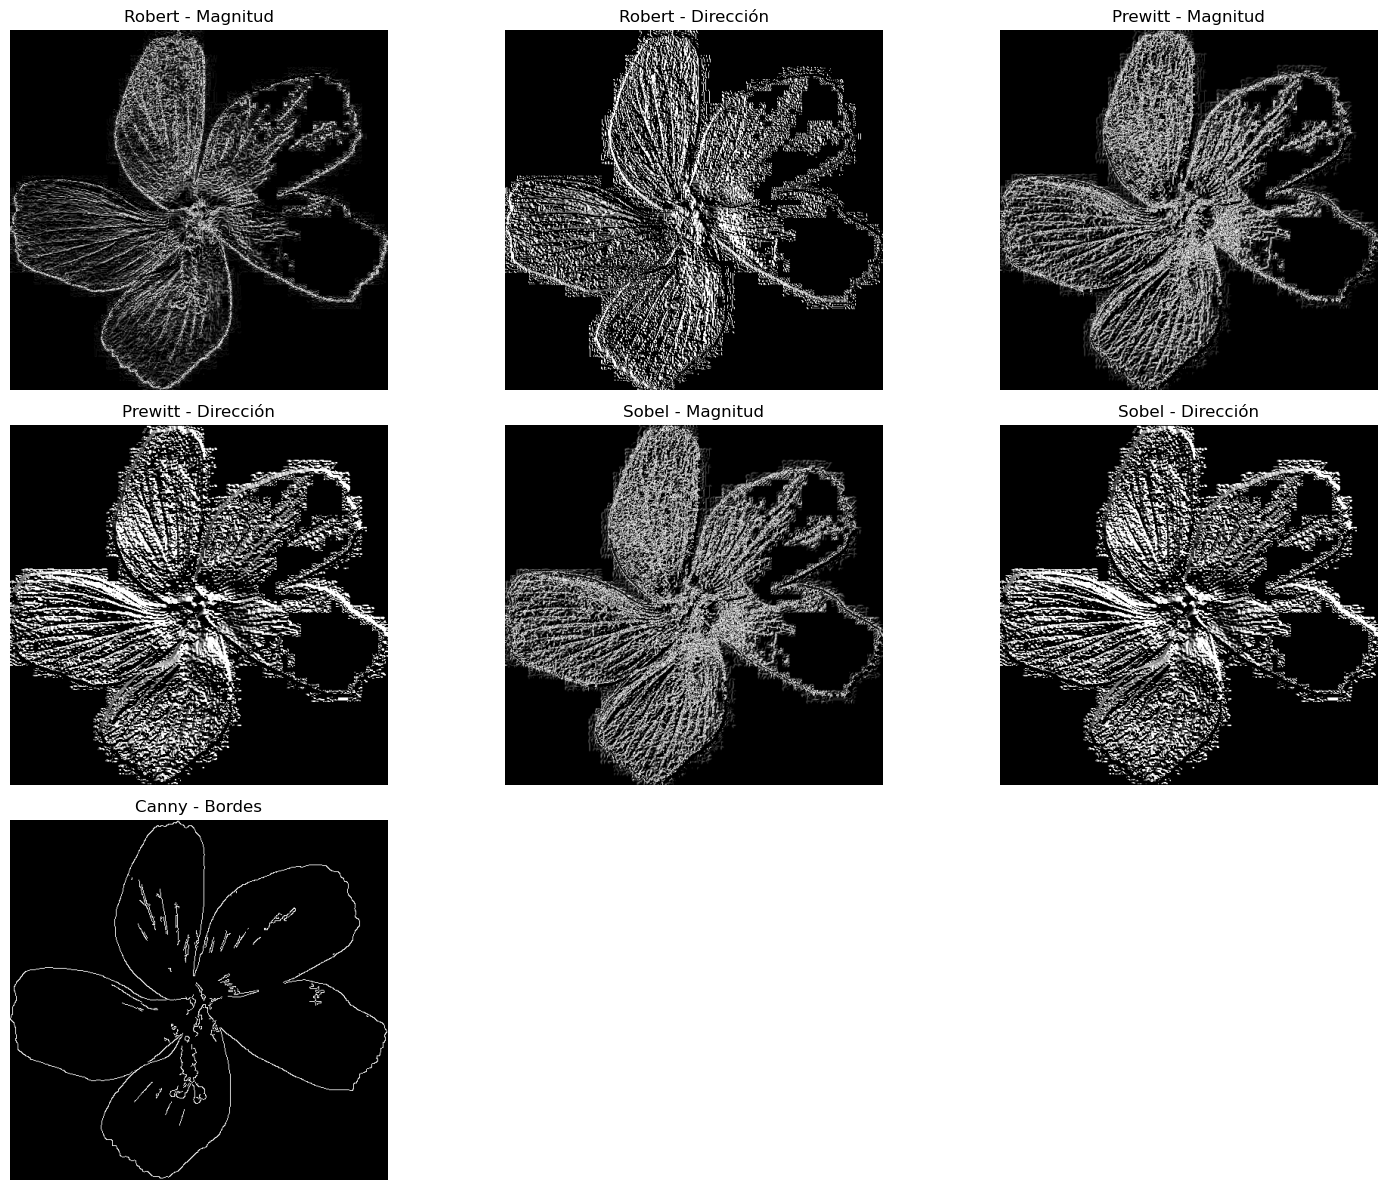

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def aplicar_roberts(imagen_gray):
    robertX = np.array([[-1, 0], [0, 1]])
    robertY = np.array([[0, -1], [1, 0]])
    img_RobX = cv2.filter2D(imagen_gray, -1, robertX)
    img_RobY = cv2.filter2D(imagen_gray, -1, robertY)
    magnitud = np.sqrt(img_RobX**2 + img_RobY**2)
    direccion = np.arctan2(img_RobY, img_RobX)
    return magnitud, direccion

def aplicar_prewitt(imagen_gray):
    prewittX = np.array([[1, 0, -1],
                         [1, 0, -1],
                         [1, 0, -1]])
    prewittY = np.array([[1, 1, 1],
                         [0, 0, 0],
                         [-1, -1, -1]])
    img_PrewX = cv2.filter2D(imagen_gray, -1, prewittX)
    img_PrewY = cv2.filter2D(imagen_gray, -1, prewittY)
    magnitud = np.sqrt(img_PrewX**2 + img_PrewY**2)
    direccion = np.arctan2(img_PrewY, img_PrewX)
    return magnitud, direccion

def aplicar_sobel(imagen_gray):
    sobelX = np.array([[1, 0, -1],
                       [2, 0, -2],
                       [1, 0, -1]])
    sobelY = np.array([[1, 2, 1],
                       [0, 0, 0],
                       [-1, -2, -1]])
    img_SobelX = cv2.filter2D(imagen_gray, -1, sobelX)
    img_SobelY = cv2.filter2D(imagen_gray, -1, sobelY)
    magnitud = np.sqrt(img_SobelX**2 + img_SobelY**2)
    direccion = np.arctan2(img_SobelY, img_SobelX)
    return magnitud, direccion

def aplicar_canny(imagen_gray, t1=100, t2=200):
    return cv2.Canny(imagen_gray, t1, t2)

def mostrar_resultados(imagen_path):
    img = cv2.imread(imagen_path)
    if img is None:
        print("No se pudo cargar la imagen.")
        return
    img_Gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    rob_mag, rob_dir = aplicar_roberts(img_Gray)
    prew_mag, prew_dir = aplicar_prewitt(img_Gray)
    sobel_mag, sobel_dir = aplicar_sobel(img_Gray)
    canny = aplicar_canny(img_Gray)

    plt.figure(figsize=(15, 12))

    # Robert
    plt.subplot(3, 3, 1)
    plt.imshow(rob_mag, cmap='gray')
    plt.title("Robert - Magnitud")
    plt.axis('off')

    plt.subplot(3, 3, 2)
    plt.imshow(rob_dir, cmap='gray')
    plt.title("Robert - Dirección")
    plt.axis('off')

    # Prewitt
    plt.subplot(3, 3, 3)
    plt.imshow(prew_mag, cmap='gray')
    plt.title("Prewitt - Magnitud")
    plt.axis('off')

    plt.subplot(3, 3, 4)
    plt.imshow(prew_dir, cmap='gray')
    plt.title("Prewitt - Dirección")
    plt.axis('off')

    # Sobel
    plt.subplot(3, 3, 5)
    plt.imshow(sobel_mag, cmap='gray')
    plt.title("Sobel - Magnitud")
    plt.axis('off')

    plt.subplot(3, 3, 6)
    plt.imshow(sobel_dir, cmap='gray')
    plt.title("Sobel - Dirección")
    plt.axis('off')

    # Canny
    plt.subplot(3, 3, 7)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny - Bordes")
    plt.axis('off')

    # Espacio vacío
    plt.subplot(3, 3, 8)
    plt.axis('off')

    plt.tight_layout()
    plt.show()
mostrar_resultados(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg")

filtro roberts mejorado

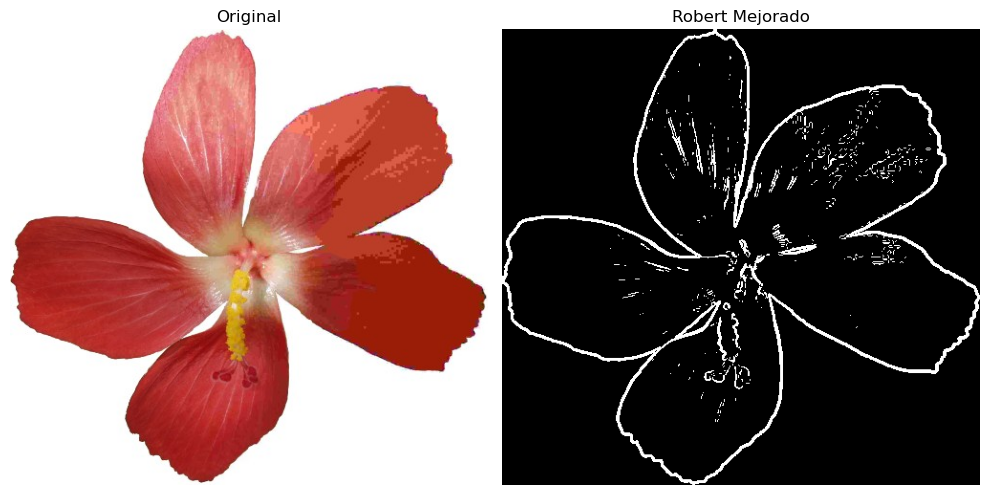

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg")
def robert_mejorado(imagen):
    img_Gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    suavisado=cv2.GaussianBlur(img_Gray,(3,3),0)
    kernelX=np.array([[-2, 0], [0, 2]],dtype=np.float32)
    kernelY=np.array([[0, 2], [-2, 0]],dtype=np.float32)
    robX=cv2.filter2D(suavisado,cv2.CV_16S,kernelX)
    robY=cv2.filter2D(suavisado,cv2.CV_16S,kernelY)
    robert=cv2.addWeighted(np.abs(robX),0.7,np.abs(robY),0.7,0)
    #resaltar bordes
    _, bordes = cv2.threshold(robert, 30, 255, cv2.THRESH_BINARY)
    return bordes
resultado = robert_mejorado(img)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Robert Mejorado")
plt.imshow(resultado, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

Sobel Mejorado

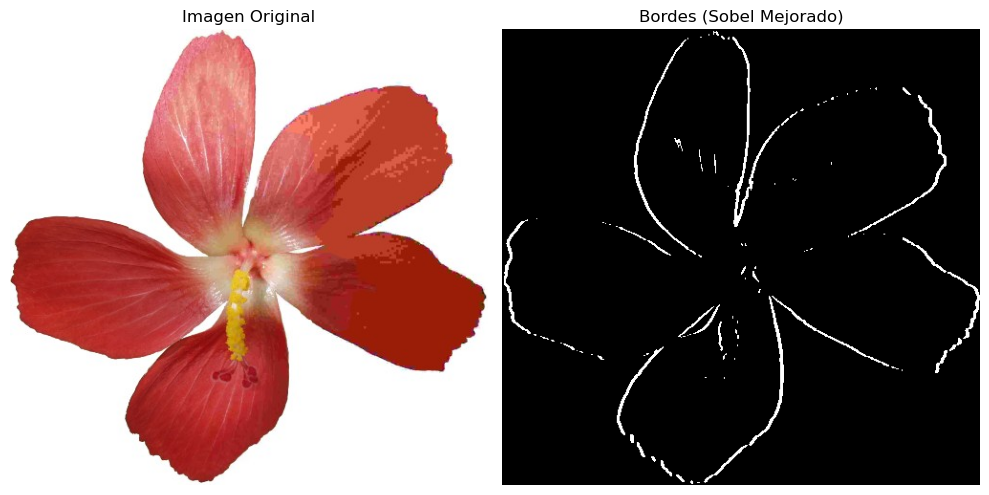

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg")
def sonel_mejorado(imagen,tam_kernel=3,umbral=30):
    img_Gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_Gray=cv2.GaussianBlur(img_Gray,(3,3),0)
    sobelX=cv2.Sobel(img_Gray,cv2.CV_64F,1,0,ksize=tam_kernel)
    sobelY=cv2.Sobel(img_Gray,cv2.CV_64F,1,0,ksize=tam_kernel)
    magnitud=np.sqrt(sobelX**2+sobelY**2)
    magnitud=cv2.normalize(magnitud,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #unir bordes
    kernel_morfologico=np.ones((2,2),np.uint8)
    bordes=cv2.morphologyEx(bordes,cv2.MORPH_CLOSE,kernel_morfologico)
    return bordes
bordes_sonel = sonel_mejorado(img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bordes_sonel, cmap='gray')
plt.title('Sobel Mejorado')
plt.axis('off')

plt.tight_layout()
plt.show()


prewitt mejorado

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_11860\1152607728.py:12: RuntimeWarning: invalid value encountered in sqrt
  magnitud=np.sqrt(preX**2+preY**2)


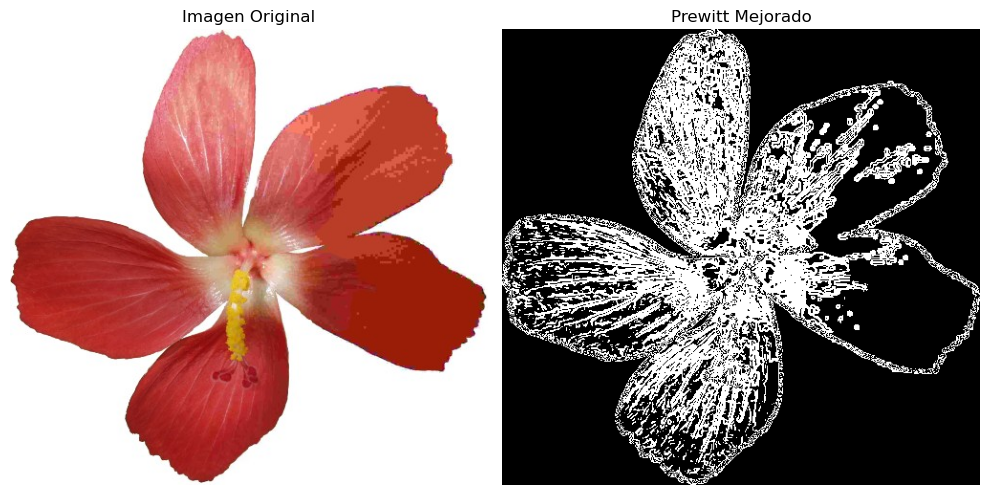

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread(r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg")
def prewitt_mejorado(imagen):
    img_Gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    img_Gray=cv2.GaussianBlur(img_Gray,(3,3),0)
    prewiitX=np.array([[3, 0,-3], [3, 0,-3],[3, 0,-3]],dtype=np.float32)
    prewiitY=np.array([[3, 3,3], [0, 0,0],[-3, -3,-3]],dtype=np.float32)
    preX=cv2.filter2D(img_Gray,cv2.CV_16S,prewiitX)
    preY=cv2.filter2D(img_Gray,cv2.CV_16S,prewiitY)
    magnitud=np.sqrt(preX**2+preY**2)
    #resaltar bordes
    _, bordes = cv2.threshold(magnitud, 30, 255, cv2.THRESH_BINARY)
    return bordes
bordes_prewitt = prewitt_mejorado(img)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bordes_prewitt, cmap='gray')
plt.title('Prewitt Mejorado')
plt.axis('off')

plt.tight_layout()
plt.show()

robert ,sobel ,preview

mostrar resultados

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_11860\1152607728.py:12: RuntimeWarning: invalid value encountered in sqrt
  magnitud=np.sqrt(preX**2+preY**2)


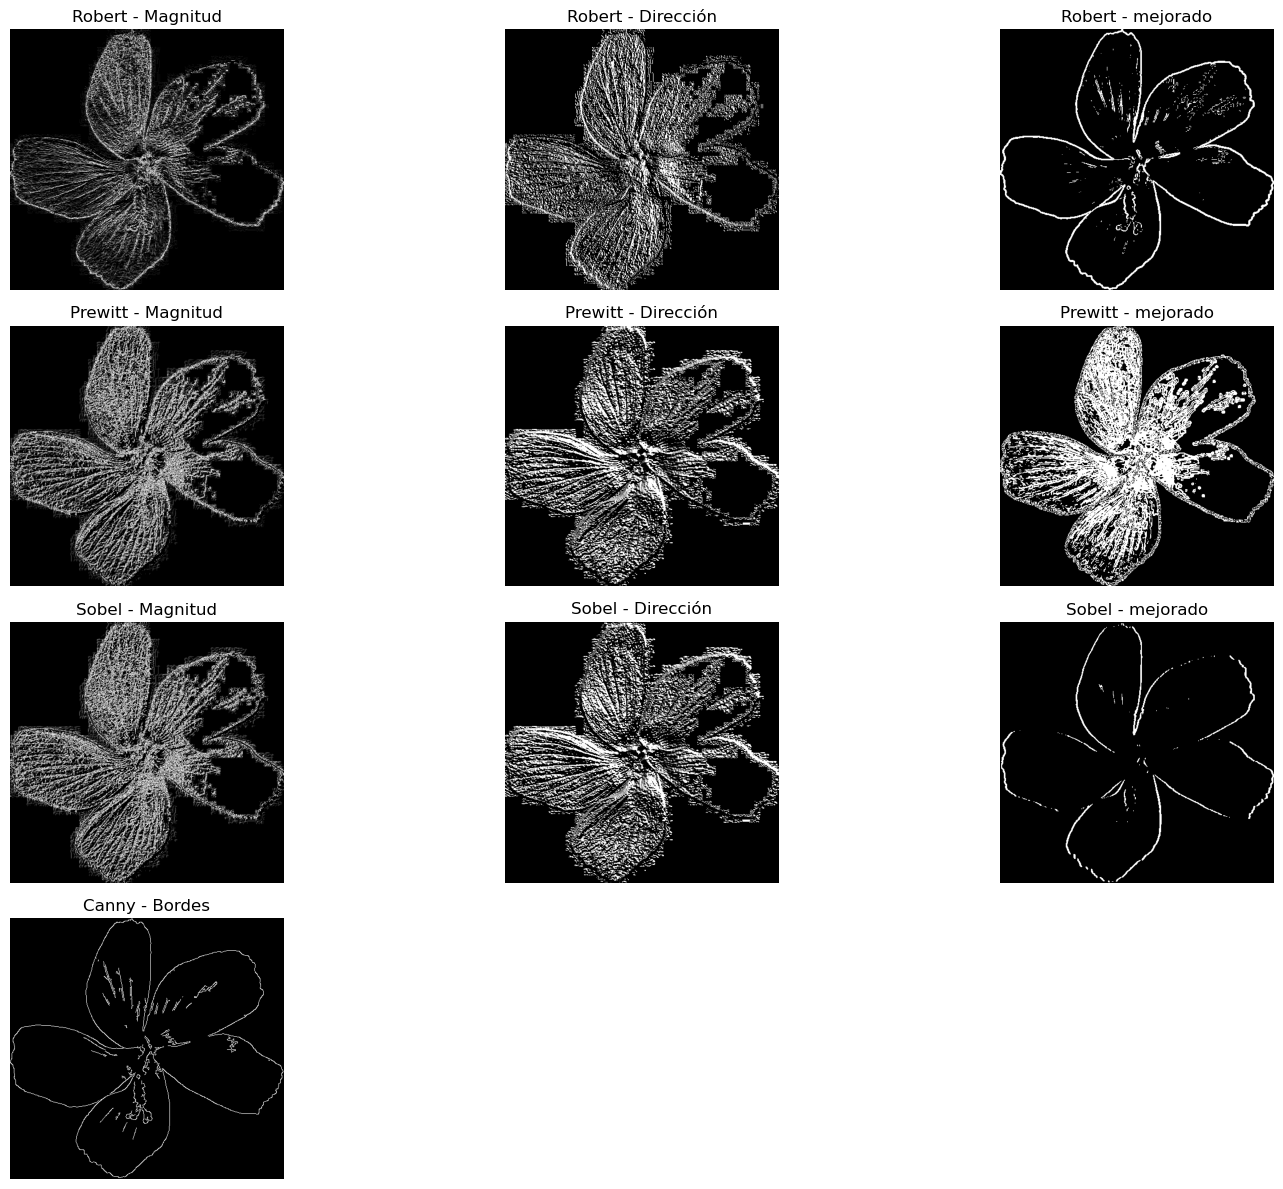

In [62]:
path = r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg"
img = cv2.imread(path)
def mostrar_resultados(imagen_path):
    img = cv2.imread(imagen_path)
    if img is None:
        print("No se pudo cargar la imagen.")
        return
    img_Gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    bordes_robert = robert_mejorado(img)
    bordes_sonel = sonel_mejorado(img)
    bordes_prewitt = prewitt_mejorado(img)
    rob_mag, rob_dir = aplicar_roberts(img_Gray)
    prew_mag, prew_dir = aplicar_prewitt(img_Gray)
    sobel_mag, sobel_dir = aplicar_sobel(img_Gray)
    canny = aplicar_canny(img_Gray)

    plt.figure(figsize=(15, 12))

    # Robert
    plt.subplot(4, 3, 1)
    plt.imshow(rob_mag, cmap='gray')
    plt.title("Robert - Magnitud")
    plt.axis('off')

    plt.subplot(4, 3, 2)
    plt.imshow(rob_dir, cmap='gray')
    plt.title("Robert - Dirección")
    plt.axis('off')

    plt.subplot(4, 3, 3)
    plt.imshow(bordes_robert, cmap='gray')
    plt.title("Robert - mejorado")
    plt.axis('off')

    # Prewitt
    plt.subplot(4, 3, 4)
    plt.imshow(prew_mag, cmap='gray')
    plt.title("Prewitt - Magnitud")
    plt.axis('off')

    plt.subplot(4, 3, 5)
    plt.imshow(prew_dir, cmap='gray')
    plt.title("Prewitt - Dirección")
    plt.axis('off')

    plt.subplot(4, 3, 6)
    plt.imshow(bordes_prewitt, cmap='gray')
    plt.title("Prewitt - mejorado")
    plt.axis('off')

    # Sobel
    plt.subplot(4, 3, 7)
    plt.imshow(sobel_mag, cmap='gray')
    plt.title("Sobel - Magnitud")
    plt.axis('off')

    plt.subplot(4, 3, 8)
    plt.imshow(sobel_dir, cmap='gray')
    plt.title("Sobel - Dirección")
    plt.axis('off')

    plt.subplot(4, 3, 9)
    plt.imshow(bordes_sonel, cmap='gray')
    plt.title("Sobel - mejorado")
    plt.axis('off')

    # Canny
    plt.subplot(4, 3, 10)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny - Bordes")
    plt.axis('off')

    # Espacio vacío
    plt.subplot(4, 3, 8)
    plt.axis('off')

    plt.tight_layout()
    plt.show()
mostrar_resultados(path)